# Storm Profile Analysis
This notebook extracts individual storm events (consecutive non-zero rainfall) and visualizes their temporal profiles to verify if the synthetic storms look like real rainfall events.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# Paths
REAL_PATH = '../data/rainfall/real_rainfall_data.csv'
SYNTH_PATH = '../results/generated_data/rainfall_synthetic_10y_v3.csv'

df_real = pd.read_csv(REAL_PATH)
df_synth = pd.read_csv(SYNTH_PATH)
df_synth.loc[df_synth['avg_rainfall'] < 0.005, "avg_rainfall"] = 0.0

col_real = df_real.columns[1] # Assuming date is col 0
col_synth = 'avg_rainfall'

def extract_storms(series, min_duration=3):
    """Extracts individual wet-period sequences."""
    is_wet = (series > 0).astype(int)
    storm_id = (is_wet != is_wet.shift()).cumsum()

    storms = []
    for _, group in series[is_wet == 1].groupby(storm_id):
        if len(group) >= min_duration:
            storms.append(group.values)
    return storms

storms_real = extract_storms(df_real[col_real])
storms_synth = extract_storms(df_synth[col_synth])

print(f"Extracted {len(storms_real)} storms from Real data.")
print(f"Extracted {len(storms_synth)} storms from Synthetic data.")

Extracted 4852 storms from Real data.
Extracted 5613 storms from Synthetic data.


## 1. Random Storm Samples
Visualizing random individual storms to check for realistic fluctuations.

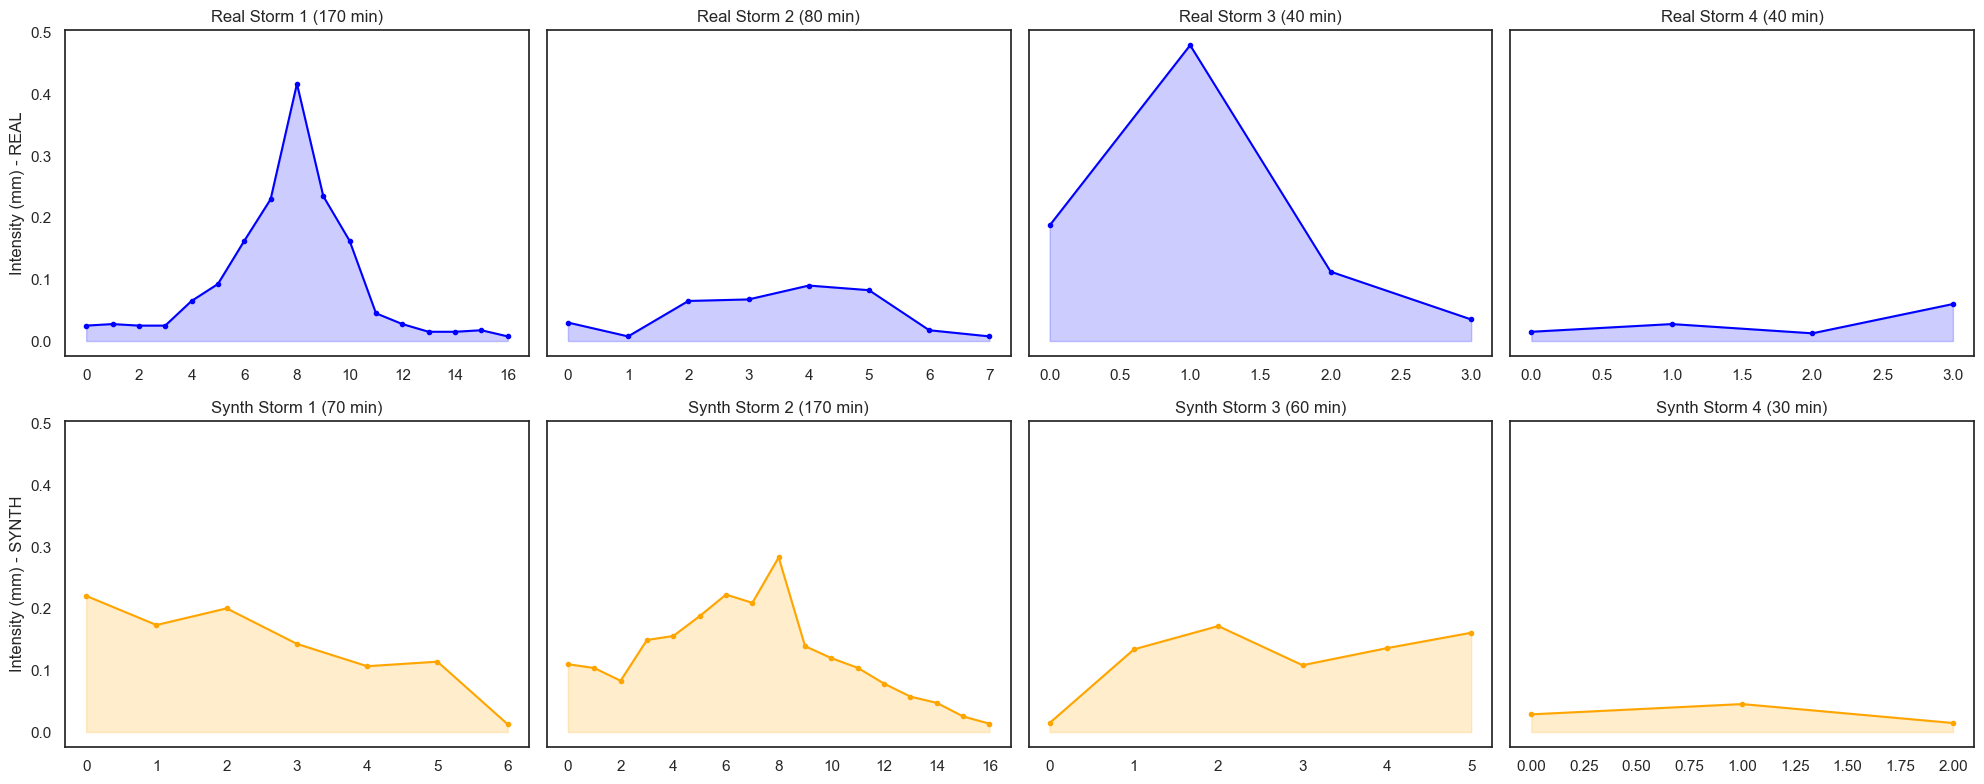

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=True)

for i in range(4):
    # Real Storms
    s_real = storms_real[np.random.randint(len(storms_real))]
    axes[0, i].plot(s_real, color='blue', marker='o', markersize=3)
    axes[0, i].set_title(f"Real Storm {i+1} ({len(s_real)*10} min)")
    axes[0, i].fill_between(range(len(s_real)), s_real, alpha=0.2, color='blue')

    # Synth Storms
    s_synth = storms_synth[np.random.randint(len(storms_synth))]
    axes[1, i].plot(s_synth, color='orange', marker='o', markersize=3)
    axes[1, i].set_title(f"Synth Storm {i+1} ({len(s_synth)*10} min)")
    axes[1, i].fill_between(range(len(s_synth)), s_synth, alpha=0.2, color='orange')

axes[0, 0].set_ylabel("Intensity (mm) - REAL")
axes[1, 0].set_ylabel("Intensity (mm) - SYNTH")
plt.tight_layout()
plt.show()

## 2. Average Storm Evolution
We normalize storms to a 0-1 time scale and overlay them to see the "Mean Storm Shape".

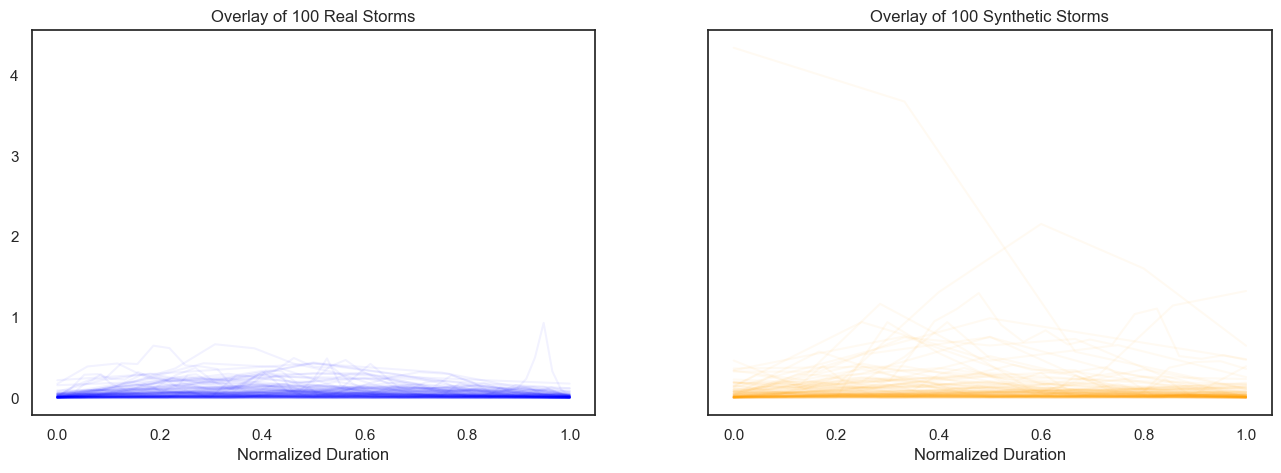

In [3]:
def plot_normalized_storms(storms, ax, label, color):
    for s in storms[:100]: # Sample 100 storms
        x = np.linspace(0, 1, len(s))
        ax.plot(x, s, color=color, alpha=0.05)

    ax.set_title(f"Overlay of 100 {label} Storms")
    ax.set_xlabel("Normalized Duration")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
plot_normalized_storms(storms_real, ax1, "Real", "blue")
plot_normalized_storms(storms_synth, ax2, "Synthetic", "orange")
plt.show()

## 3. Peak Timing
Does the peak rainfall occur at the same relative time in the storm?

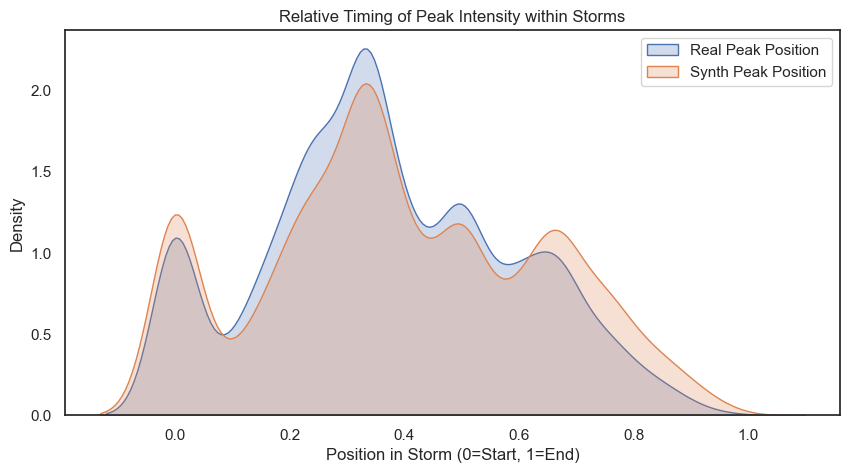

In [4]:
def get_peak_pos(storms):
    return [np.argmax(s) / len(s) for s in storms]

peak_real = get_peak_pos(storms_real)
peak_synth = get_peak_pos(storms_synth)

plt.figure(figsize=(10, 5))
sns.kdeplot(peak_real, label="Real Peak Position", fill=True)
sns.kdeplot(peak_synth, label="Synth Peak Position", fill=True)
plt.title("Relative Timing of Peak Intensity within Storms")
plt.xlabel("Position in Storm (0=Start, 1=End)")
plt.legend()
plt.show()

In [5]:
durations_real = np.array([len(s) for s in storms_real])
durations_synth = np.array([len(s) for s in storms_synth])

for name, durations in [("Real", durations_real), ("Synthetic", durations_synth)]:
  print(f"{name} storms:")
  print(f"  count: {len(durations)}")
  print(f"  min duration: {durations.min()} steps ({durations.min() * 10} min)")
  print(f"  max duration: {durations.max()} steps ({durations.max() * 10} min)")
  print(f"  avg duration: {durations.mean():.2f} steps ({durations.mean() * 10:.1f} min)")
  print()

Real storms:
  count: 4852
  min duration: 3 steps (30 min)
  max duration: 222 steps (2220 min)
  avg duration: 10.00 steps (100.0 min)

Synthetic storms:
  count: 5613
  min duration: 3 steps (30 min)
  max duration: 52 steps (520 min)
  avg duration: 7.67 steps (76.7 min)



In [6]:
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

# 1. Define the improved HMM Fitting Function
def fit_hmm_on_storms(storms, n_states=4, random_state=42):
    # Calculate lengths for each storm sequence
    lengths = [len(s) for s in storms]
    X = np.concatenate(storms).reshape(-1, 1)

    model = GaussianHMM(
        n_components=n_states,
        covariance_type="diag",
        n_iter=500, # Increased iterations for better convergence
        random_state=random_state,
    )

    # Fit the model
    model.fit(X, lengths=lengths)

    # --- Critical: Sort states by mean intensity (Ascending) ---
    # This ensures State 0 is 'Light' and State 3 is 'Heavy' for both models
    idx = np.argsort(model.means_.flatten())
    model.means_ = model.means_[idx].reshape(n_states, 1)
    model.covars_ = model.covars_[idx].reshape(n_states, 1)
    model.transmat_ = model.transmat_[np.ix_(idx, idx)]
    model.startprob_ = model.startprob_[idx]

    # Predict states for the data
    states = model.predict(X, lengths=lengths)
    return model, X.flatten(), states

# 2. Define the Summary Function
def summarize_hmm(model, states, label):
    means = model.means_.flatten()
    variances = model.covars_.flatten()
    counts = np.bincount(states, minlength=model.n_components)
    total = len(states)

    print(f"=== {label} HMM Analysis ===")
    for s in range(model.n_components):
        print(f"  State {s}: mean={means[s]:.4f}, std={np.sqrt(variances[s]):.4f}, occupancy={counts[s]/total:.2%}")
    print()

# 3. Storm Extraction Logic (if not already run)
def extract_storms(series, min_duration=3):
    is_wet = (series > 0).astype(int)
    storm_id = (is_wet != is_wet.shift()).cumsum()
    storms = []
    for _, group in series[is_wet == 1].groupby(storm_id):
        if len(group) >= min_duration:
            storms.append(group.values)
    return storms

# --- EXECUTION ---
# Assuming df_real and df_synth are already loaded in your notebook
# Extraction
storms_real = extract_storms(df_real[df_real.columns[1]]) # adjust column index if needed
storms_synth = extract_storms(df_synth['avg_rainfall'])
print(f"Extracted {len(storms_real)} real and {len(storms_synth)} synthetic storms.\n")

# Fitting
model_real, X_real, states_real = fit_hmm_on_storms(storms_real, n_states=4)
model_synth, X_synth, states_synth = fit_hmm_on_storms(storms_synth, n_states=4)

# Summarizing
summarize_hmm(model_real, states_real, "Real Data")
summarize_hmm(model_synth, states_synth, "Synthetic Data")

Extracted 4852 real and 5613 synthetic storms.

=== Real Data HMM Analysis ===
  State 0: mean=0.0176, std=0.0101, occupancy=33.74%
  State 1: mean=0.0685, std=0.0312, occupancy=33.08%
  State 2: mean=0.2090, std=0.0891, occupancy=25.92%
  State 3: mean=0.7220, std=0.5956, occupancy=7.26%

=== Synthetic Data HMM Analysis ===
  State 0: mean=0.0172, std=0.0093, occupancy=32.25%
  State 1: mean=0.0687, std=0.0330, occupancy=35.32%
  State 2: mean=0.2201, std=0.1035, occupancy=25.40%
  State 3: mean=0.8409, std=0.6622, occupancy=7.04%

